# Section 0. Title, purpose, and key distinction

This notebook reproduces the current minimal DMC + variational evidence + Wong-Wang flow, then adds a single-trial repeated stochastic forward diagnostic.

**single-condition distribution**: many different trials from the same condition, such as incongruent trials, are pooled into one RT distribution.

**single-trial repeated distribution**: the same fixed trial is passed through the fixed model many times while resampling stochastic evidence and decision noise.

Human data usually have one RT observation per real trial, so human single-trial RT distributions are not directly observable. The model can generate this distribution by repeated stochastic forward passes. The goal here is to test whether the current model has this internal RT and choice variability, and whether it comes mostly from Stage-1 variational evidence noise or Wong-Wang internal noise.

# Section 1. Copy and reproduce the current notebook pipeline

The front half of this notebook follows the existing `examples/dmc_var_ww_minimal_pipeline.ipynb` logic: imports, project paths, seed, real-data loading, cached Stage-1 logits, variational evidence sampling, DMC modulation, Wong-Wang recurrent dynamics, soft-index readout, evaluation, saving, and visualization.

The original notebook is not modified. This notebook does not retrain by default. It loads the current DMC + Var->WW smoke artifacts, then freezes the model parameters before the single-trial probe.

In [1]:
from pathlib import Path
import csv, json, math, os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (
            (candidate / "examples").exists()
            and (candidate / "data").exists()
            and (candidate / "artifacts").exists()
        ):
            return candidate
    raise FileNotFoundError(
        "Could not find project root. Run this notebook from the repo root or from examples/."
    )

PROJECT_ROOT = find_project_root()
OUT_DIR = PROJECT_ROOT / "artifacts/results/rt_model_dmc_var_ww/single_trial_rt_probe"
FIG_DIR = OUT_DIR / "figures"
RUN_DIR = PROJECT_ROOT / "artifacts/results/rt_model_dmc_var_ww/smoke_a5_s3_neg_drt"
DATA_DIR = PROJECT_ROOT / "data/age_groups_matched/20-29"
LOGITS_PATH = PROJECT_ROOT / "artifacts/checkpoints/age_groups_matched/20-29/stage2/test_logits.npz"
PRED_PATH = RUN_DIR / "predictions_neg_drt.npz"
PARAM_PATH = RUN_DIR / "best_model_params.npz"
CONFIG_PATH = RUN_DIR / "config.json"
SUMMARY_SMOKE_PATH = PROJECT_ROOT / "artifacts/results/rt_model_dmc_var_ww/summary_smoke.md"
CLASS_NAMES = ["L", "R", "U", "D"]
CLASS_TO_INT = {name: i for i, name in enumerate(CLASS_NAMES)}
INT_TO_CLASS = {i: name for i, name in enumerate(CLASS_NAMES)}
SEED = 20260409
N_REPEATS = 500
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Output directory:", OUT_DIR)
print("This is a diagnostic repeated-forward probe, not a formal trained-model result.")

Output directory: /Users/siyu/Documents/GitHub/VAM-studying/artifacts/results/rt_model_dmc_var_ww/single_trial_rt_probe
This is a diagnostic repeated-forward probe, not a formal trained-model result.


In [2]:
# Regenerate all diagnostic artifacts if needed.
# This imports the local builder used to create the notebook and reruns the same fixed-parameter diagnostic probe.
# It is safe to skip this cell if the CSV/figure files already exist.
import importlib.util

builder_path = PROJECT_ROOT / "examples/build_single_trial_rt_variability_probe.py"
spec = importlib.util.spec_from_file_location("single_trial_probe_builder", builder_path)
probe_builder = importlib.util.module_from_spec(spec)
spec.loader.exec_module(probe_builder)
artifact_stats = probe_builder.make_artifacts()
{
    "n_eval": artifact_stats["n_eval"],
    "n_selected": artifact_stats["n_selected"],
    "n_repeated": artifact_stats["n_repeated"],
    "n_ablation": artifact_stats["n_ablation"],
    "output_dir": str(OUT_DIR),
}

{'n_eval': 1024,
 'n_selected': 12,
 'n_repeated': 6000,
 'n_ablation': 32,
 'output_dir': '/Users/siyu/Documents/GitHub/VAM-studying/artifacts/results/rt_model_dmc_var_ww/single_trial_rt_probe'}

# Section 2. Load real human experimental data and trained artifacts

This section loads real 20-29 test trial rows, cached Stage-1 logits, current DMC + Var->WW config/parameters, previous prediction files, and `summary_smoke.md` when present.

In [3]:
test_df = pd.read_csv(DATA_DIR / "test_data.csv")
logits_npz = np.load(LOGITS_PATH, allow_pickle=True)
pred_npz = np.load(PRED_PATH, allow_pickle=True)
params = np.load(PARAM_PATH, allow_pickle=True)
config = json.loads(CONFIG_PATH.read_text())
summary_smoke = SUMMARY_SMOKE_PATH.read_text() if SUMMARY_SMOKE_PATH.exists() else ""

print("human trial rows:", len(test_df))
print("cached logits:", logits_npz["logits"].shape)
print("prediction arrays:", {k: pred_npz[k].shape for k in pred_npz.files})
print("checkpoint parameters:", params.files)
print("run config:", config)
print(summary_smoke[:1200])

human trial rows: 33134
cached logits: (33134, 4)
prediction arrays: {'pred_rt': (1024,), 'pred_choice': (1024,), 'target_labels': (1024,), 'response_labels': (1024,), 'congruency': (1024,), 'true_rt': (1024,)}
checkpoint parameters: ['log_scale', 'ww.a', 'ww.b', 'ww.d', 'ww.gamma', 'ww.tau_s', 'ww.J_matrix', 'ww.J_ext', 'ww.I_0', 'ww.noise_ampa', 'ww.tau_ampa', 'ww.threshold']
run config: {'readout_mode': 'soft_index', 'readout_config': {'dt_ms': 10.0, 'choice_temperature': 0.1, 'sigma_s': 0.05, 't0_mode': 'fixed_global', 't0_seconds': 0.25}, 'behavioral_loss_config': {'lambda_error_rate': 0.75, 'lambda_error_sign': 1.5, 'lambda_accuracy': 0.0, 'lambda_response_nll': 1.0, 'lambda_rt_mse': 0.0}, 'ww_time_steps': 120, 'evidence_time_steps': 120, 'epochs_stage1': 5, 'epochs_ww': 11, 'noise_ampa': 0.08, 'threshold': 0.22, 'j_offdiag_scale': None, 'j_ext': None, 'dmc_auto_strength': 0.5, 'dmc_auto_peak_s': 0.06, 'dmc_selection_strength': 0.3, 'dmc_selection_midpoint_s': 0.18, 'dmc_selectio

# Section 3. Overall model performance visualization

The generated files in `single_trial_rt_probe/` summarize human-vs-model RT shape, condition differences, quantiles, accuracy, and response agreement.

,source,n,mean_rt,median_rt,std_rt,skewness,q05,q25,q50,q75,q95,q95_minus_q50,error_minus_correct_rt,congruency_gap_incongruent_minus_congruent,target_accuracy,response_agreement
0,human,1024,0.610322,0.600000,0.089189,0.584478,0.521150,0.563750,0.600000,0.641000,0.750000,0.150000,-0.037828,-0.039043,0.868164,NaN
1,model,1024,0.453140,0.437231,0.113801,0.807752,0.297548,0.365341,0.437231,0.521212,0.672562,0.235331,-0.017622,-0.046517,0.823242,0.734375


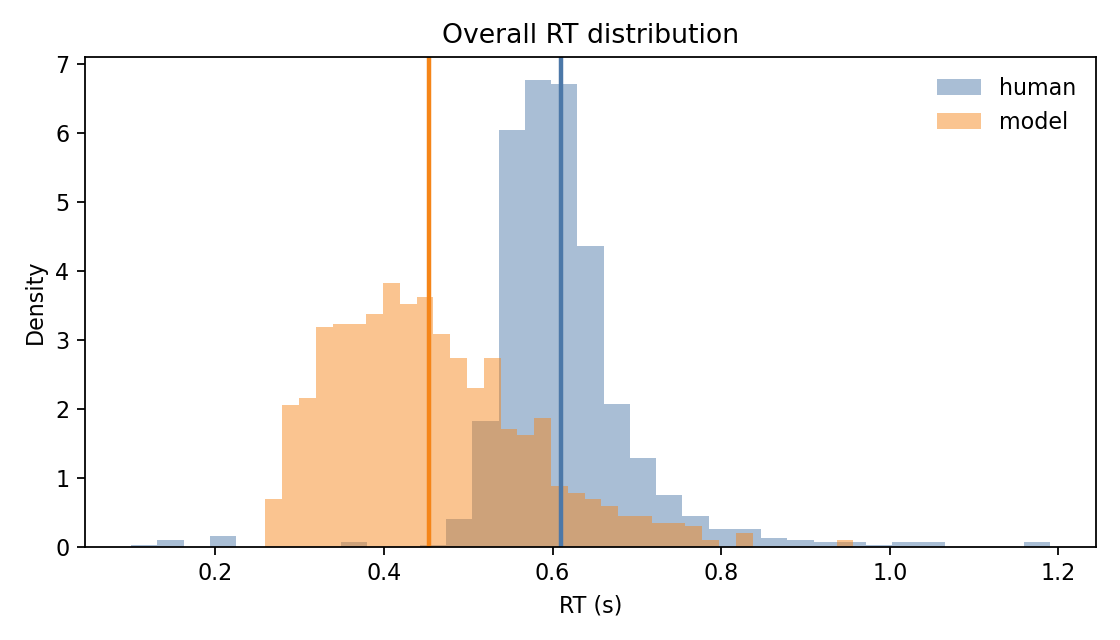

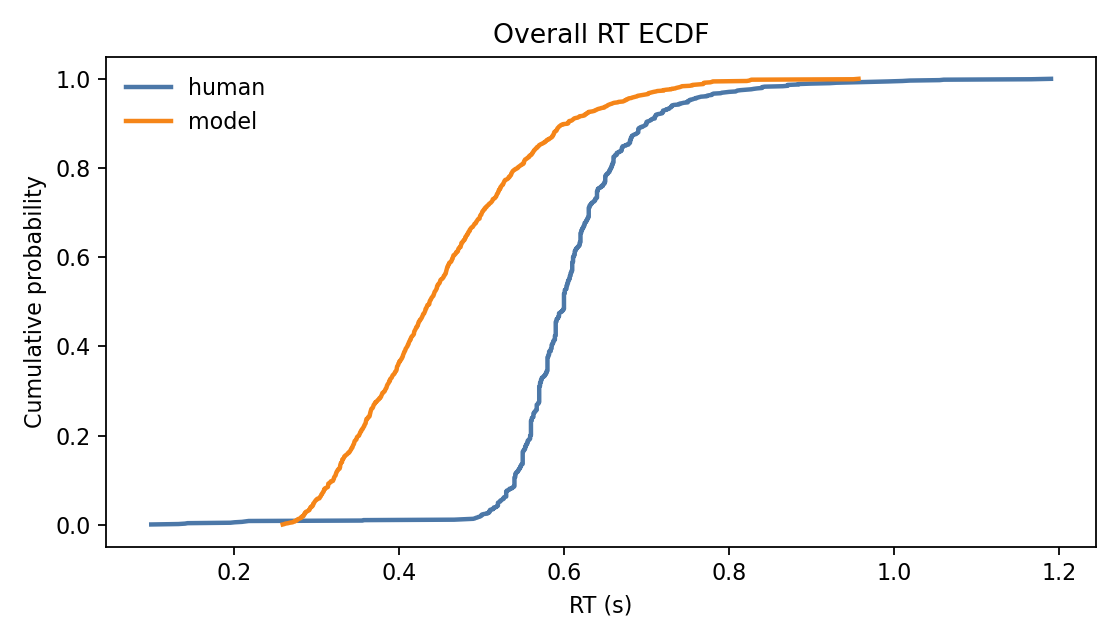

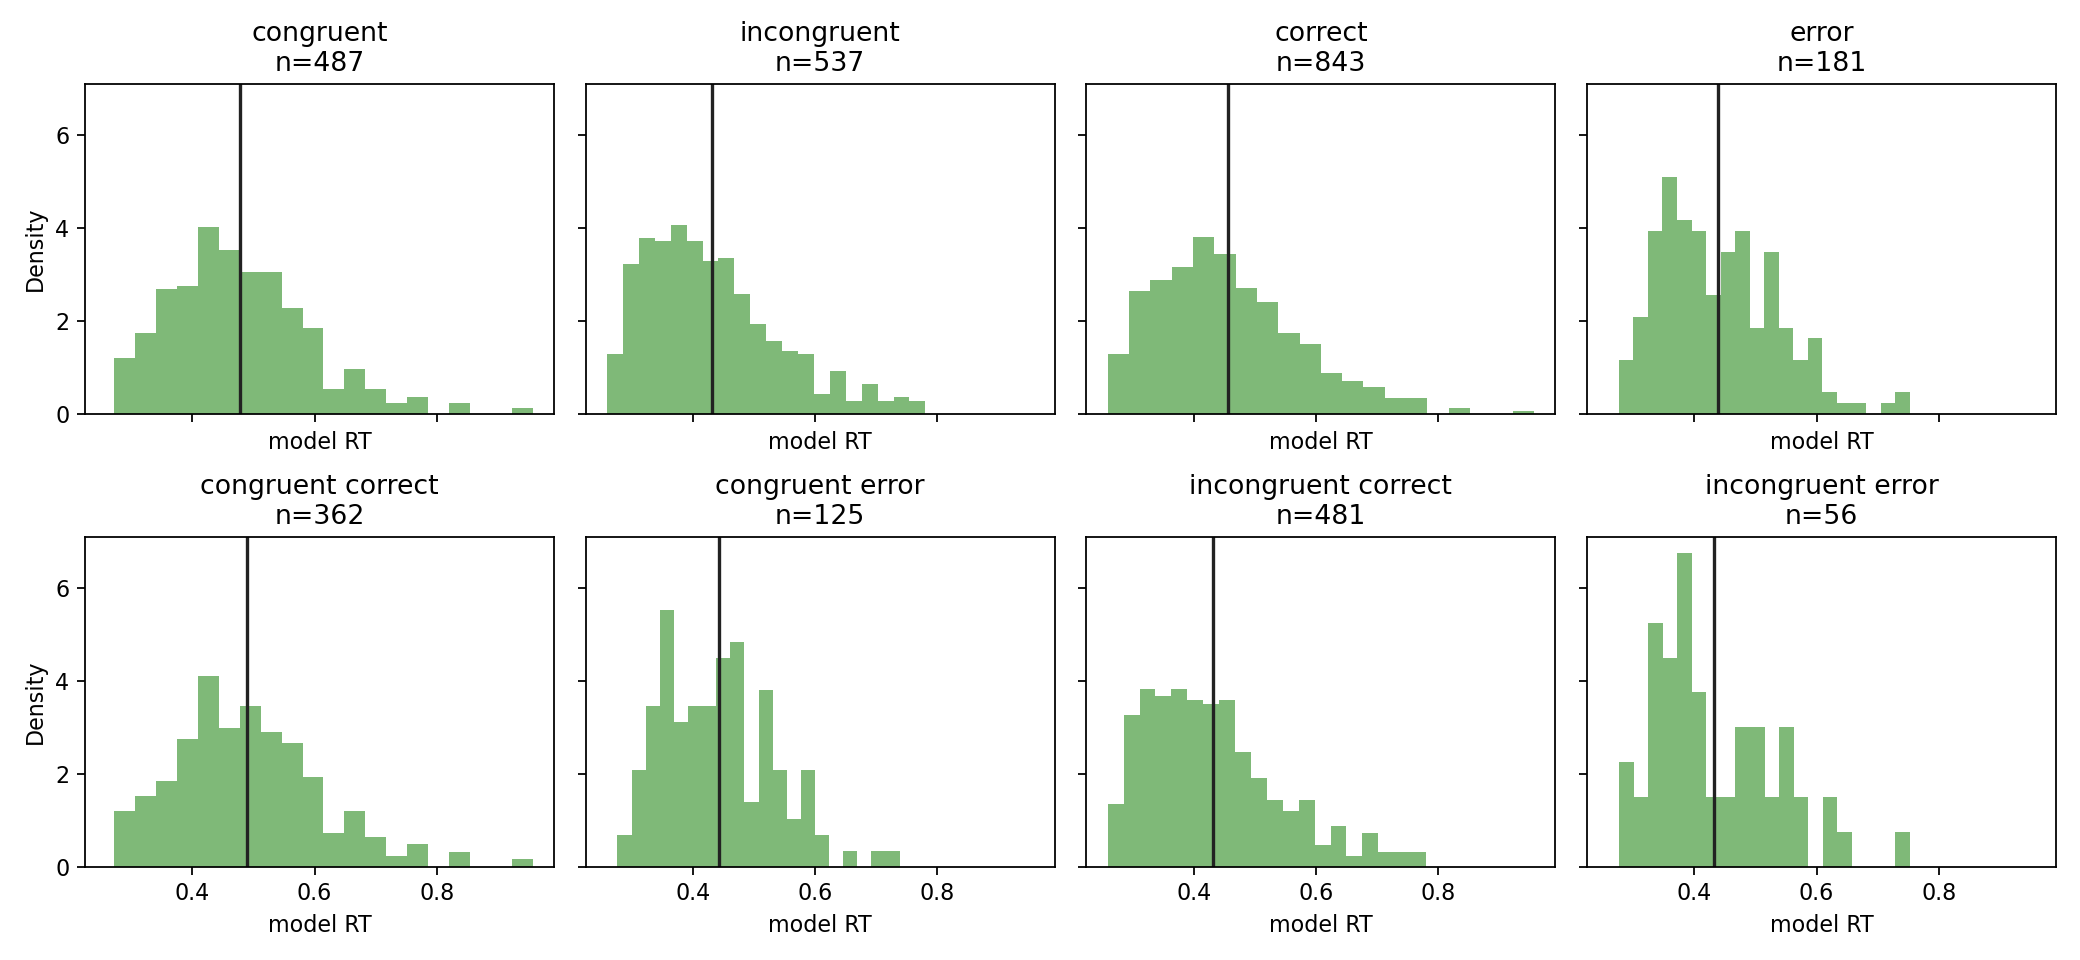

In [4]:
overall = pd.read_csv(OUT_DIR / "overall_model_performance_summary.csv")
display(overall)
from IPython.display import Image, display as ipy_display
for name in ["overall_rt_distribution.png", "overall_rt_ecdf.png", "overall_condition_rt_distributions.png"]:
    ipy_display(Image(filename=str(FIG_DIR / name)))

Interpretation: the saved smoke summary reports that the model is right-skewed, has a nonzero right-tail spread, is overall faster than human RT, and should still be treated as a mechanism test rather than a final fit.

# Section 4. Explain evidence sampling mechanism

Current variational evidence sampling is:

`mu, sigma = variational_head(pooled_features)`

`evidence = mu.unsqueeze(1) + sigma.unsqueeze(1) * noise`

Shapes:

- `mu: [B, 4]`
- `sigma: [B, 4]`
- `noise: [B, T, 4]`
- `evidence: [B, T, 4]`

For one trial, `mu` and `sigma` are fixed across time. Every time step and direction gets a fresh `epsilon_t ~ N(0,1)`. This means the default evidence noise is time-step independent, not temporally correlated evidence noise.

In [5]:
selected = pd.read_csv(OUT_DIR / "selected_trials.csv")
repeated = pd.read_csv(OUT_DIR / "repeated_forward_predictions.csv")
dist_summary = pd.read_csv(OUT_DIR / "single_trial_rt_distribution_summary.csv")
print("Selected trials:", len(selected))
display(selected)
display(dist_summary)

Selected trials: 12


,trial_id,subject_id,age_group,target,flanker,congruency,human_rt,human_response,human_correct,existing_model_pred_rt,existing_model_pred_choice,reason_selected
0,test_000030,677,20-29,U,U,congruent,0.690,U,True,0.510195,U,congruent human-correct trial
1,test_000042,677,20-29,D,D,congruent,0.624,L,False,0.672759,D,congruent human-error trial
2,test_000151,677,20-29,L,U,incongruent,0.571,L,True,0.446153,L,incongruent human-correct trial
3,test_000498,677,20-29,D,L,incongruent,0.563,L,False,0.408110,D,incongruent human-error trial
4,test_021835,677,20-29,L,R,incongruent,0.100,L,True,0.285689,L,human fast RT trial
5,test_030475,677,20-29,U,U,congruent,1.190,U,True,0.463840,U,human slow RT trial
6,test_009269,677,20-29,L,L,congruent,0.733,L,True,0.276255,U,model likely fast-error trial
7,test_016903,677,20-29,U,U,congruent,0.657,U,True,0.956805,U,model likely slow-correct trial
8,test_000187,677,20-29,R,R,congruent,0.530,D,False,0.567025,R,additional target/flanker coverage
9,test_000337,677,20-29,L,D,incongruent,0.551,L,True,0.449797,L,additional target/flanker coverage


,trial_id,n_repeats,mean_rt,median_rt,std_rt,min_rt,max_rt,q05,q25,q75,...,error_probability_relative_to_target,matches_human_response_probability,choice_consistency,modal_predicted_choice,probability_of_target_choice,probability_of_flanker_choice,fast_error_rate,broad_narrow_classification,skew_classification,possible_multimodality_flag
0,test_000030,500,0.425443,0.409807,0.076141,0.290404,0.732035,0.328636,0.369595,0.466639,...,0.760,0.240,0.336,L,0.240,0.240,0.200,broad,right-skewed,True
1,test_000042,500,0.433033,0.420658,0.075475,0.270032,0.685693,0.333323,0.377140,0.477823,...,0.664,0.200,0.336,D,0.336,0.336,0.180,broad,right-skewed,True
2,test_000151,500,0.426125,0.416435,0.077232,0.265883,0.701684,0.320538,0.371293,0.470005,...,0.718,0.282,0.282,L,0.282,0.258,0.176,broad,right-skewed,True
3,test_000498,500,0.427839,0.412485,0.085283,0.277854,0.820978,0.317651,0.367556,0.473236,...,0.682,0.202,0.318,D,0.318,0.202,0.170,broad,right-skewed,True
4,test_021835,500,0.428093,0.417510,0.077673,0.277815,0.714489,0.321827,0.371493,0.471636,...,0.712,0.288,0.288,L,0.288,0.244,0.182,broad,right-skewed,True
5,test_030475,500,0.425885,0.409304,0.076820,0.267348,0.845296,0.325197,0.372282,0.469644,...,0.738,0.262,0.280,D,0.262,0.262,0.180,broad,right-skewed,True
6,test_009269,500,0.426876,0.414138,0.078416,0.275735,0.710642,0.317036,0.370856,0.473283,...,0.746,0.254,0.272,U,0.254,0.254,0.182,broad,right-skewed,True
7,test_016903,500,0.432183,0.416369,0.087042,0.286539,0.853212,0.318219,0.373962,0.473445,...,0.742,0.258,0.270,D,0.258,0.258,0.194,broad,right-skewed,True
8,test_000187,500,0.429831,0.418605,0.081563,0.264474,0.791876,0.320445,0.370519,0.480924,...,0.772,0.240,0.302,U,0.228,0.228,0.184,broad,right-skewed,True
9,test_000337,500,0.428339,0.421651,0.076465,0.279629,0.676169,0.320648,0.370835,0.472574,...,0.710,0.290,0.290,L,0.290,0.250,0.170,broad,right-skewed,True


# Section 5. Explain DMC modulation

DMC does not directly produce RT or update the WW state. It modulates the evidence sequence before evidence enters WW. By default, congruent trials are unchanged; incongruent trials get early flanker boost and late target support / flanker suppression.

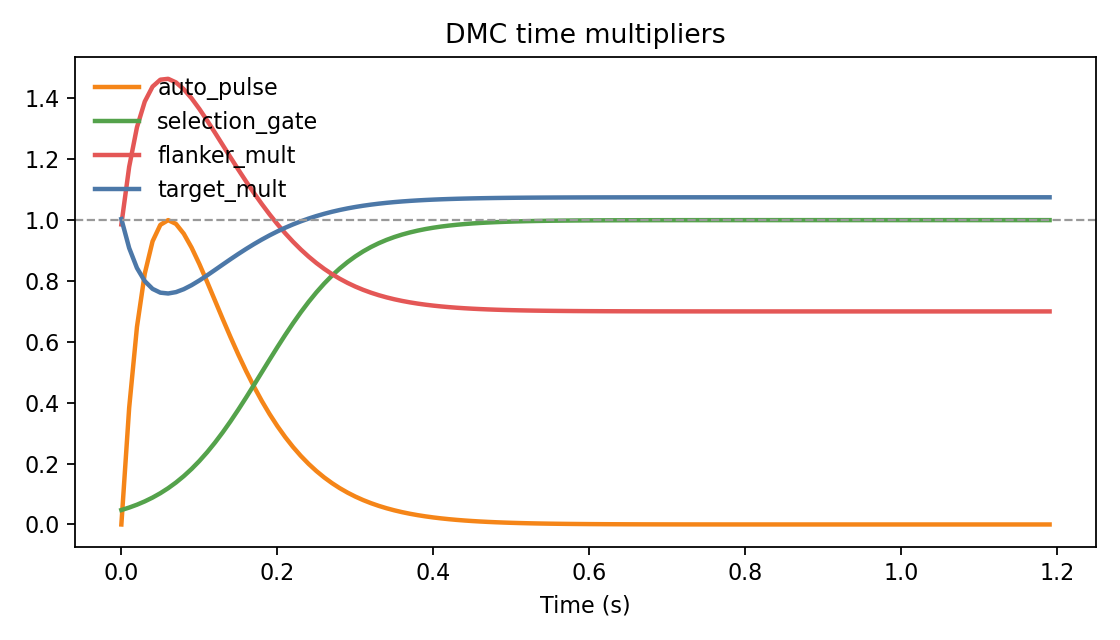

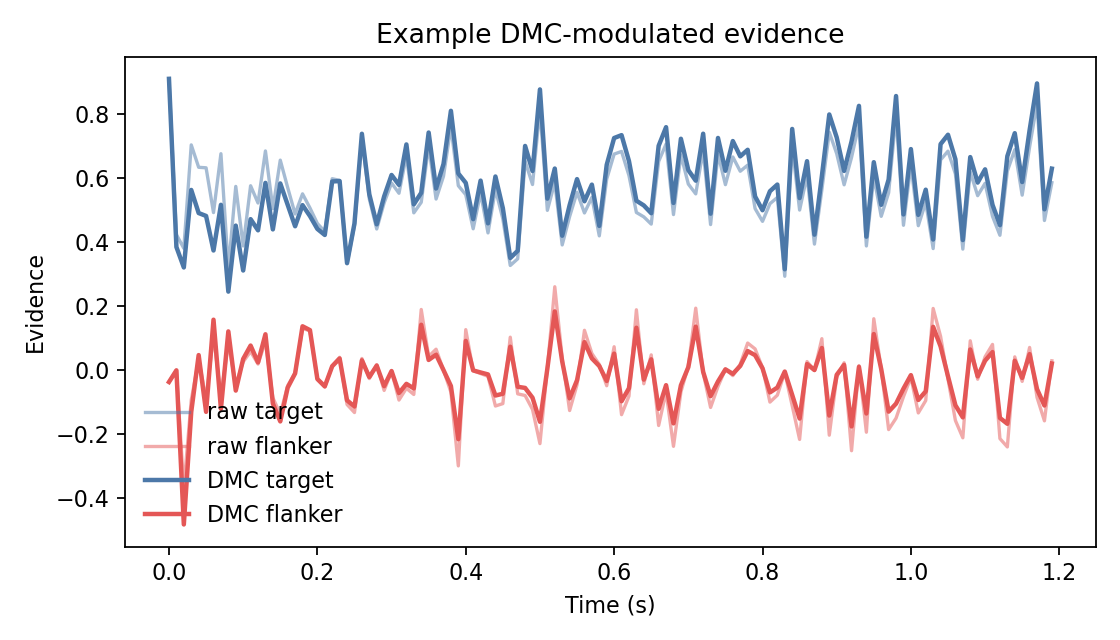

In [6]:
from IPython.display import Image, display as ipy_display
ipy_display(Image(filename=str(FIG_DIR / "dmc_time_multipliers.png")))
ipy_display(Image(filename=str(FIG_DIR / "example_dmc_modulated_evidence.png")))

# Section 6. Explain Wong-Wang recurrent accumulation

Input at each step is `ww_input[t] = [left, right, up, down]`.

`I_t = J_ext * ww_input_t`

Internal state is `s_t = [s_left, s_right, s_up, s_down]`.

`x_t = s_t @ J_matrix + I_0 + I_t + I_noise_t`

`H_t = nonlinear_transfer(x_t)`

`ds/dt = -s_t / tau_s + (1 - s_t) * H_t * gamma / 1000`

`s_{t+1} = s_t + ds/dt * dt`

`s_t` is the recurrent decision state, not the original Stage-1 evidence. The diagonal of `J_matrix` is self-excitation. The off-diagonal entries are lateral inhibition. `trajectory - threshold` is a threshold-relative decision trajectory, not Stage-1 evidence.

In [7]:
J = params["ww.J_matrix"]
s = np.array([0.30, 0.10, 0.05, 0.02])
recurrent_input = s @ J
toy = pd.DataFrame({"class": CLASS_NAMES, "state_s": s, "recurrent_input": recurrent_input})
display(toy)

,class,state_s,recurrent_input
0,L,0.30,0.069626
1,R,0.10,0.008072
2,U,0.05,-0.007439
3,D,0.02,-0.017650


# Section 7. Explain DiffDecision vs soft_index readout

`DiffDecisionMultiClass` finds the first threshold-crossing time for each class from `trajectory - threshold`. It exists to provide crossing-time computation and an approximate backward path.

`soft_index` then places a Gaussian window around each class crossing, reads class evidence near that crossing, softmaxes class evidence into `choice_probs`, and computes `pred_rt` as a probability-weighted class-wise decision time.

In the current config, `readout_mode` is `soft_index`, so the final `pred_rt` mainly comes from `compute_soft_index_readout(evidence_traj)`. `DiffDecision` may still be called inside WW to compute class-wise crossing time, but soft-index is the final RT/choice readout strategy.

# Section 8. Select representative real trials

In [8]:
display(selected)

,trial_id,subject_id,age_group,target,flanker,congruency,human_rt,human_response,human_correct,existing_model_pred_rt,existing_model_pred_choice,reason_selected
0,test_000030,677,20-29,U,U,congruent,0.690,U,True,0.510195,U,congruent human-correct trial
1,test_000042,677,20-29,D,D,congruent,0.624,L,False,0.672759,D,congruent human-error trial
2,test_000151,677,20-29,L,U,incongruent,0.571,L,True,0.446153,L,incongruent human-correct trial
3,test_000498,677,20-29,D,L,incongruent,0.563,L,False,0.408110,D,incongruent human-error trial
4,test_021835,677,20-29,L,R,incongruent,0.100,L,True,0.285689,L,human fast RT trial
5,test_030475,677,20-29,U,U,congruent,1.190,U,True,0.463840,U,human slow RT trial
6,test_009269,677,20-29,L,L,congruent,0.733,L,True,0.276255,U,model likely fast-error trial
7,test_016903,677,20-29,U,U,congruent,0.657,U,True,0.956805,U,model likely slow-correct trial
8,test_000187,677,20-29,R,R,congruent,0.530,D,False,0.567025,R,additional target/flanker coverage
9,test_000337,677,20-29,L,D,incongruent,0.551,L,True,0.449797,L,additional target/flanker coverage


# Section 9. Repeated stochastic forward for single-trial variability

In [9]:
print("N repeated-forward rows:", len(repeated))
display(repeated.head())

N repeated-forward rows: 6000


,trial_id,repeat_id,seed,subject_id,age_group,target,flanker,congruency,human_rt,human_response,...,mean_evidence_target,mean_evidence_flanker,early_evidence_target,early_evidence_flanker,late_evidence_target,late_evidence_flanker,stage1_noise_on,ww_noise_on,model_run_id,checkpoint_path
0,test_000030,0,20260409,677,20-29,U,U,congruent,0.69,U,...,-0.462874,-0.462874,-0.485914,-0.485914,-0.465713,-0.465713,True,True,smoke_a5_s3_neg_drt,artifacts/results/rt_model_dmc_var_ww/smoke_a5...
1,test_000030,1,20260410,677,20-29,U,U,congruent,0.69,U,...,-0.443911,-0.443911,-0.450810,-0.450810,-0.452699,-0.452699,True,True,smoke_a5_s3_neg_drt,artifacts/results/rt_model_dmc_var_ww/smoke_a5...
2,test_000030,2,20260411,677,20-29,U,U,congruent,0.69,U,...,-0.476883,-0.476883,-0.468729,-0.468729,-0.482555,-0.482555,True,True,smoke_a5_s3_neg_drt,artifacts/results/rt_model_dmc_var_ww/smoke_a5...
3,test_000030,3,20260412,677,20-29,U,U,congruent,0.69,U,...,-0.437647,-0.437647,-0.418735,-0.418735,-0.447183,-0.447183,True,True,smoke_a5_s3_neg_drt,artifacts/results/rt_model_dmc_var_ww/smoke_a5...
4,test_000030,4,20260413,677,20-29,U,U,congruent,0.69,U,...,-0.460842,-0.460842,-0.479254,-0.479254,-0.435992,-0.435992,True,True,smoke_a5_s3_neg_drt,artifacts/results/rt_model_dmc_var_ww/smoke_a5...


# Section 10. Single-trial RT distribution summary

In [10]:
display(dist_summary)

,trial_id,n_repeats,mean_rt,median_rt,std_rt,min_rt,max_rt,q05,q25,q75,...,error_probability_relative_to_target,matches_human_response_probability,choice_consistency,modal_predicted_choice,probability_of_target_choice,probability_of_flanker_choice,fast_error_rate,broad_narrow_classification,skew_classification,possible_multimodality_flag
0,test_000030,500,0.425443,0.409807,0.076141,0.290404,0.732035,0.328636,0.369595,0.466639,...,0.760,0.240,0.336,L,0.240,0.240,0.200,broad,right-skewed,True
1,test_000042,500,0.433033,0.420658,0.075475,0.270032,0.685693,0.333323,0.377140,0.477823,...,0.664,0.200,0.336,D,0.336,0.336,0.180,broad,right-skewed,True
2,test_000151,500,0.426125,0.416435,0.077232,0.265883,0.701684,0.320538,0.371293,0.470005,...,0.718,0.282,0.282,L,0.282,0.258,0.176,broad,right-skewed,True
3,test_000498,500,0.427839,0.412485,0.085283,0.277854,0.820978,0.317651,0.367556,0.473236,...,0.682,0.202,0.318,D,0.318,0.202,0.170,broad,right-skewed,True
4,test_021835,500,0.428093,0.417510,0.077673,0.277815,0.714489,0.321827,0.371493,0.471636,...,0.712,0.288,0.288,L,0.288,0.244,0.182,broad,right-skewed,True
5,test_030475,500,0.425885,0.409304,0.076820,0.267348,0.845296,0.325197,0.372282,0.469644,...,0.738,0.262,0.280,D,0.262,0.262,0.180,broad,right-skewed,True
6,test_009269,500,0.426876,0.414138,0.078416,0.275735,0.710642,0.317036,0.370856,0.473283,...,0.746,0.254,0.272,U,0.254,0.254,0.182,broad,right-skewed,True
7,test_016903,500,0.432183,0.416369,0.087042,0.286539,0.853212,0.318219,0.373962,0.473445,...,0.742,0.258,0.270,D,0.258,0.258,0.194,broad,right-skewed,True
8,test_000187,500,0.429831,0.418605,0.081563,0.264474,0.791876,0.320445,0.370519,0.480924,...,0.772,0.240,0.302,U,0.228,0.228,0.184,broad,right-skewed,True
9,test_000337,500,0.428339,0.421651,0.076465,0.279629,0.676169,0.320648,0.370835,0.472574,...,0.710,0.290,0.290,L,0.290,0.250,0.170,broad,right-skewed,True


# Section 11. Single-trial figures

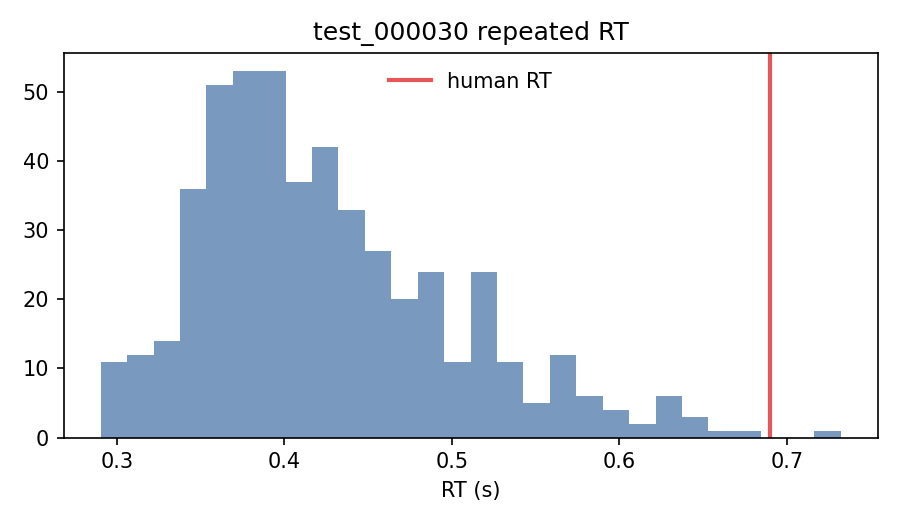

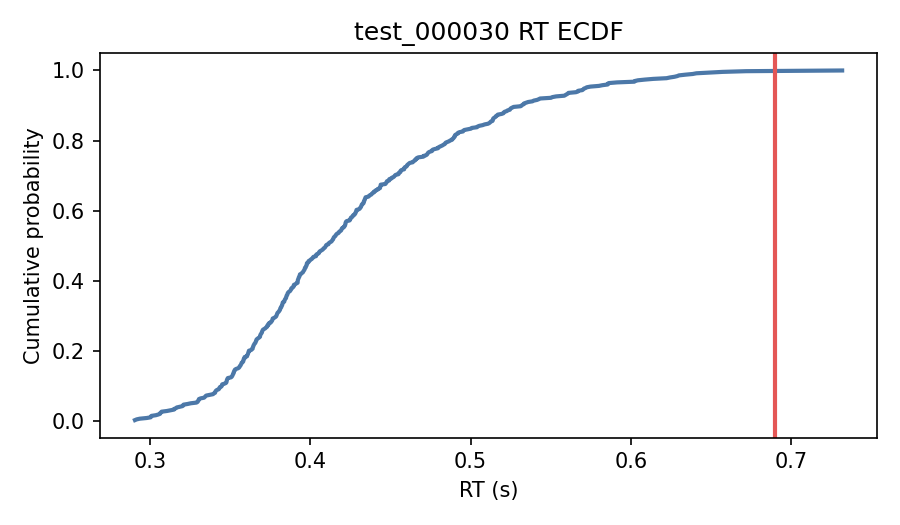

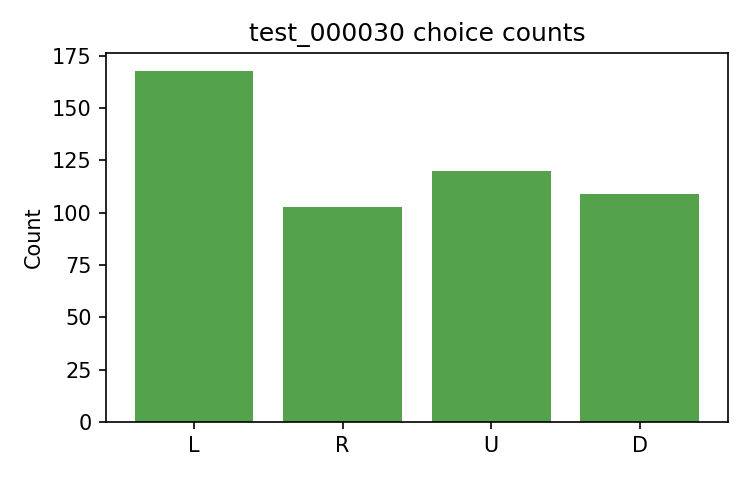

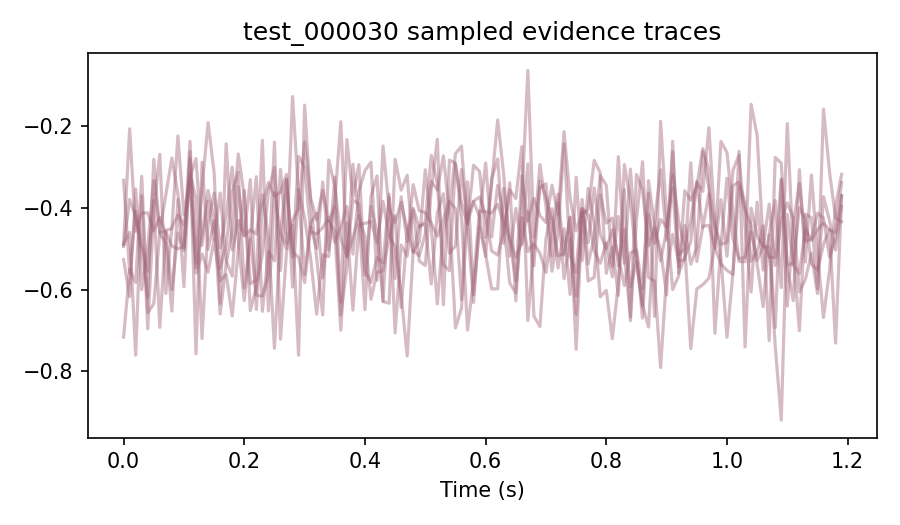

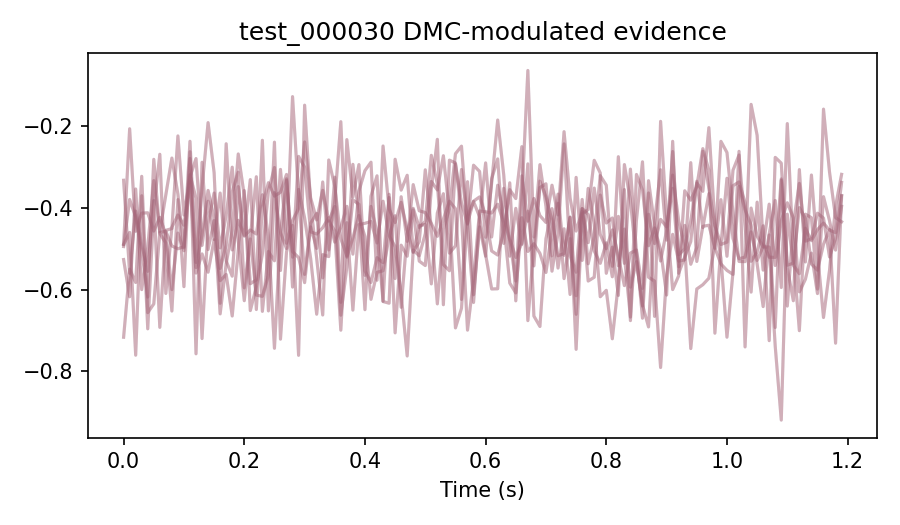

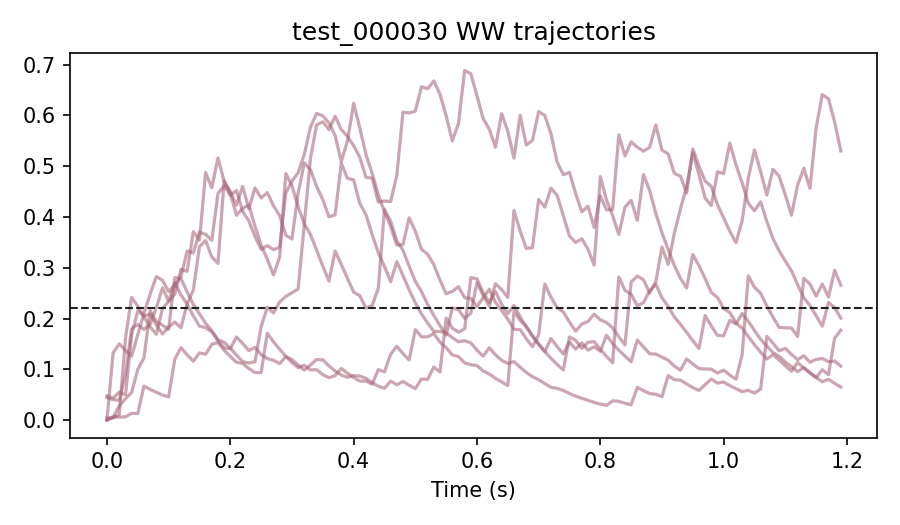

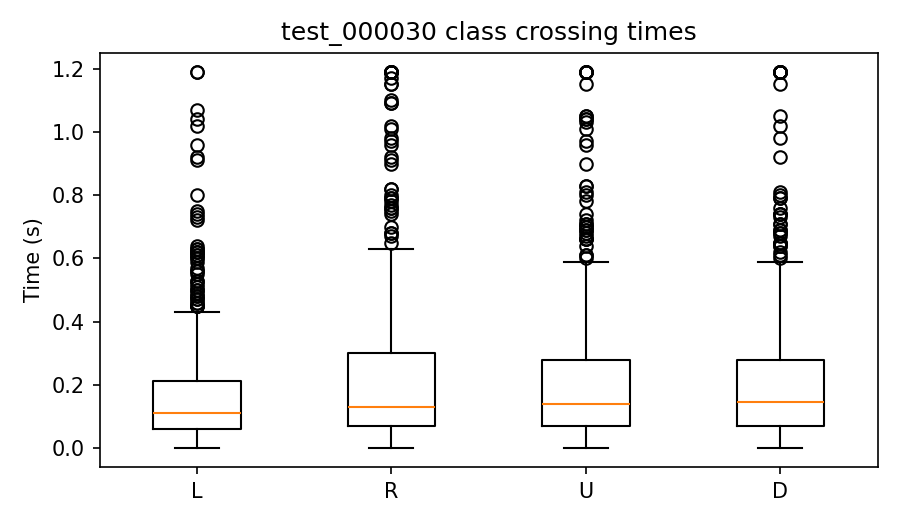

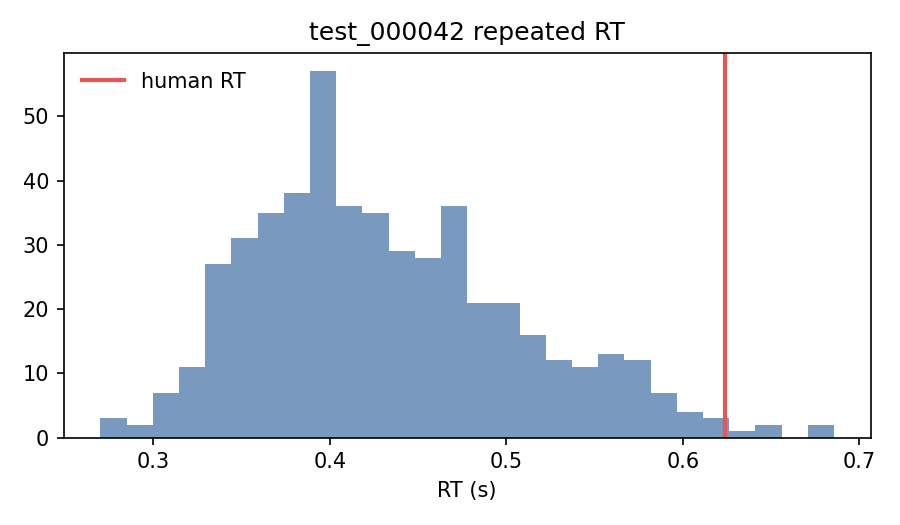

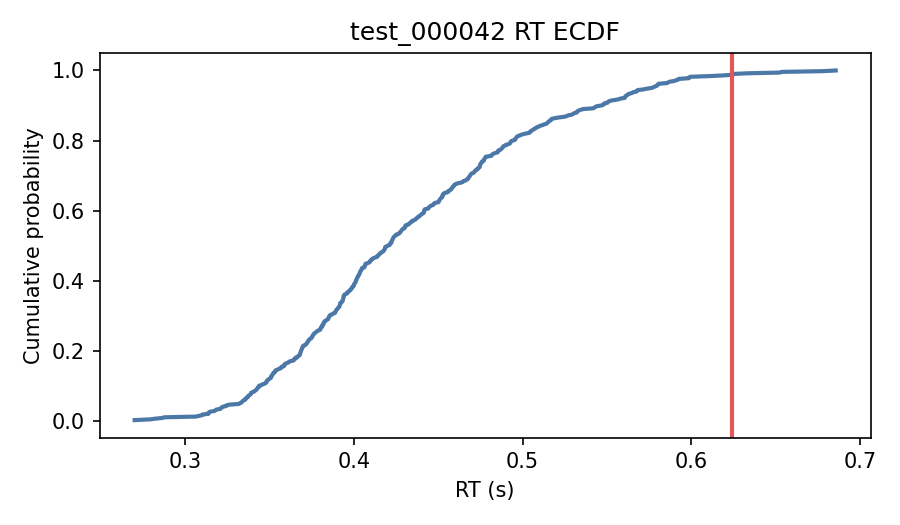

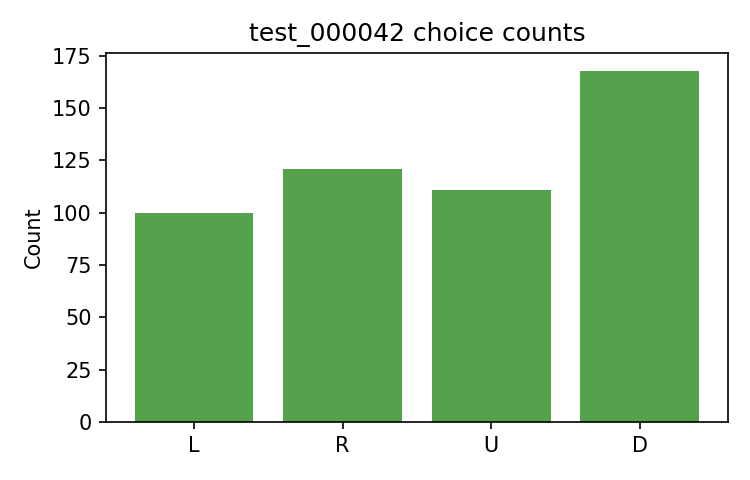

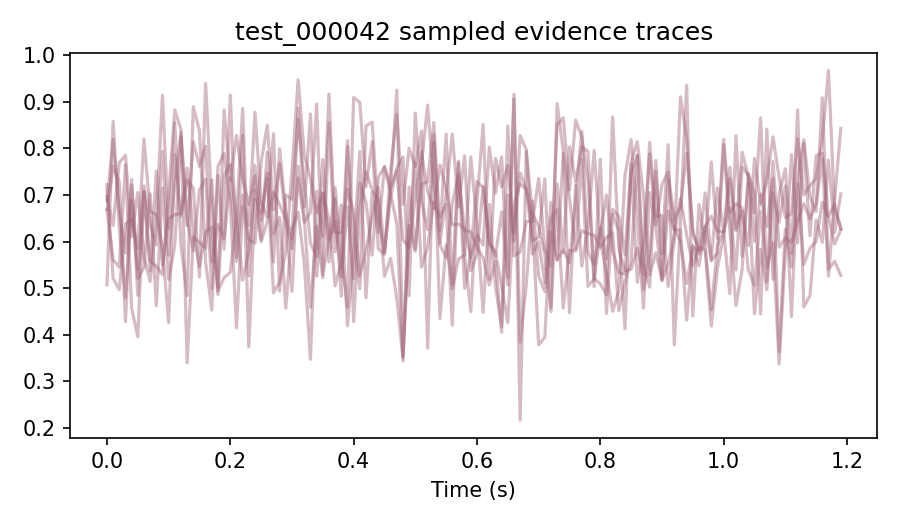

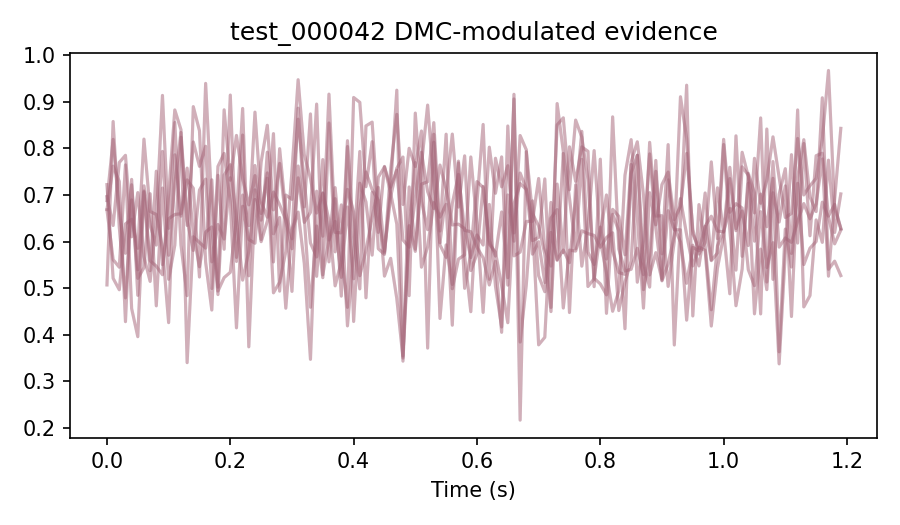

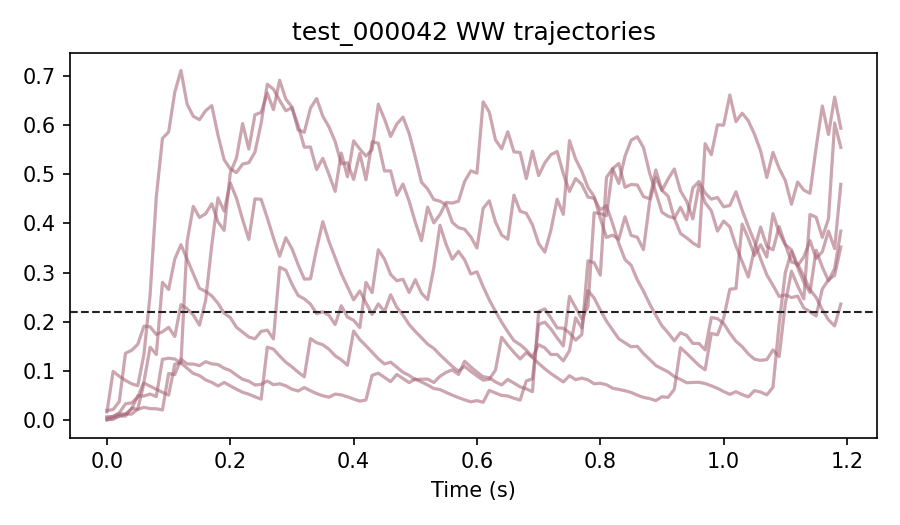

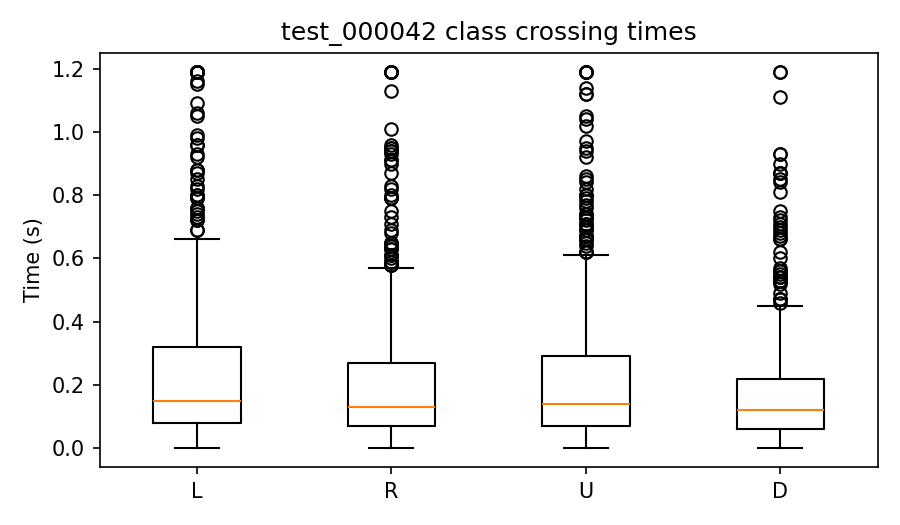

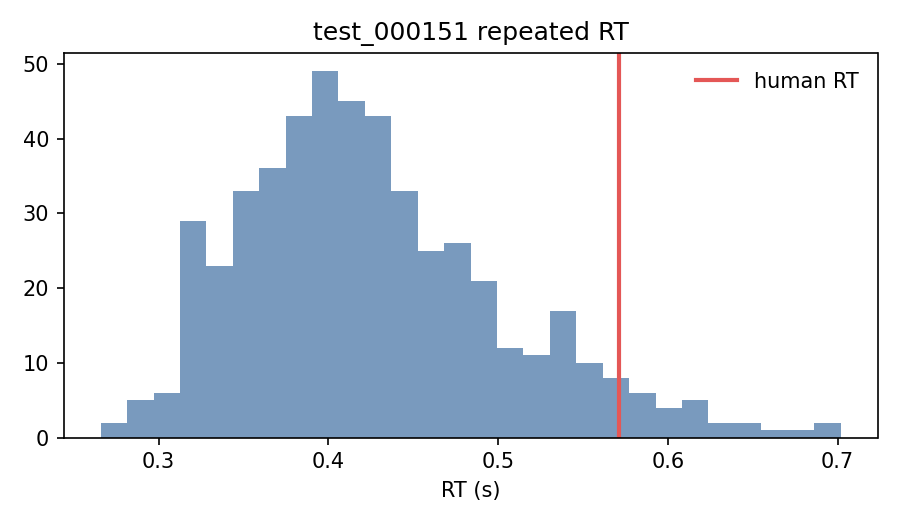

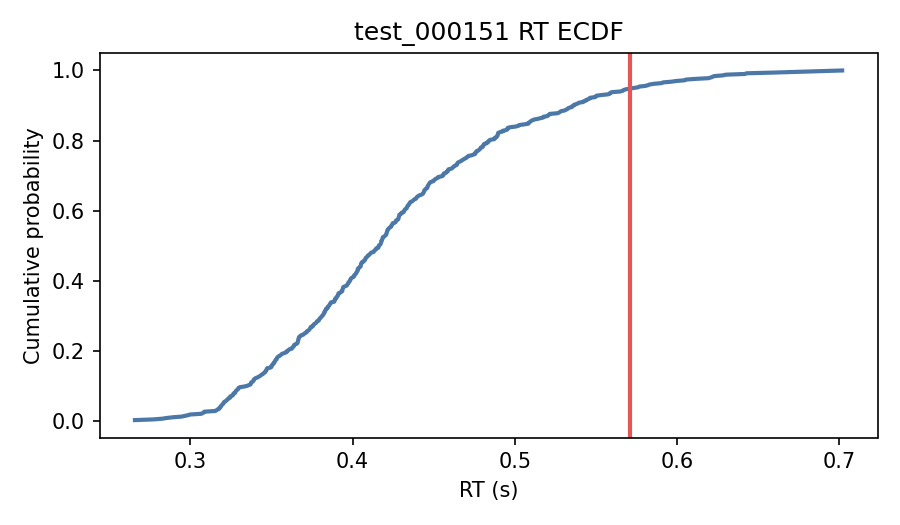

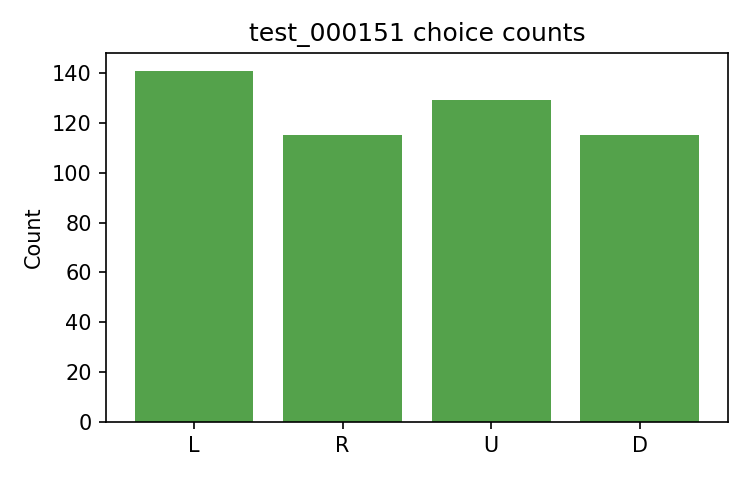

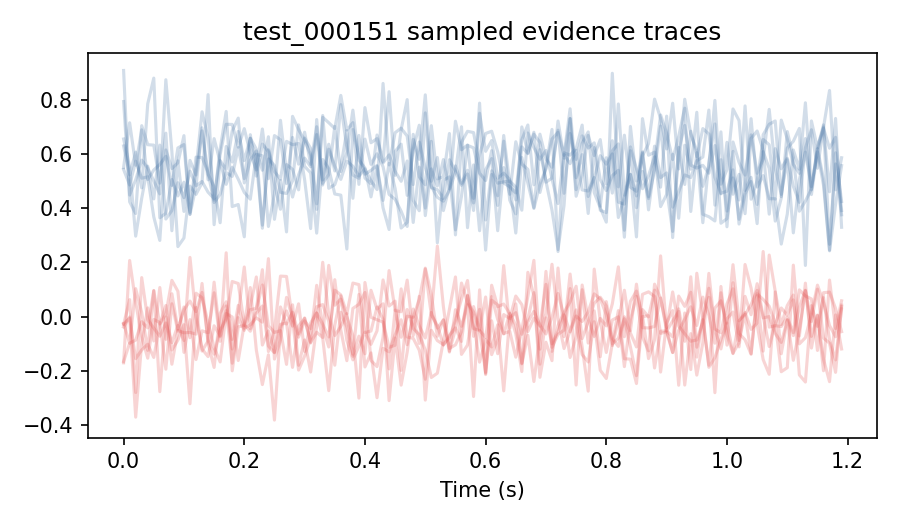

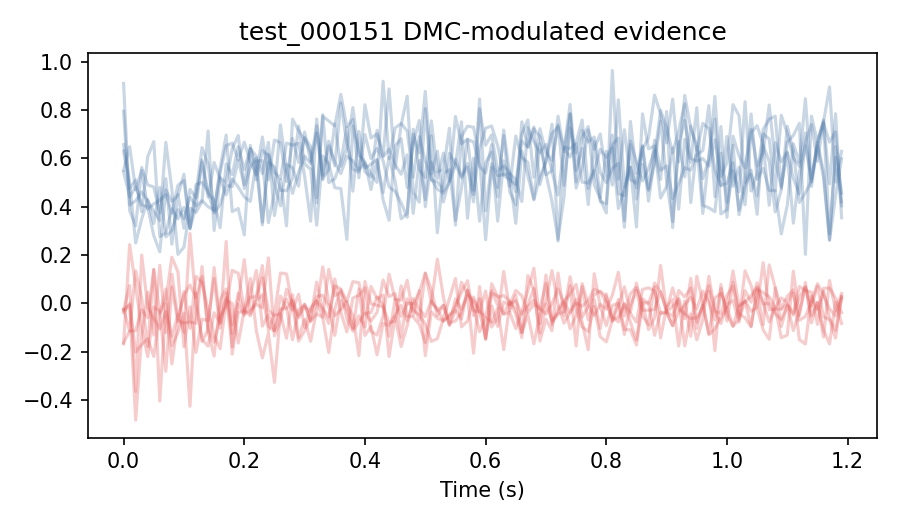

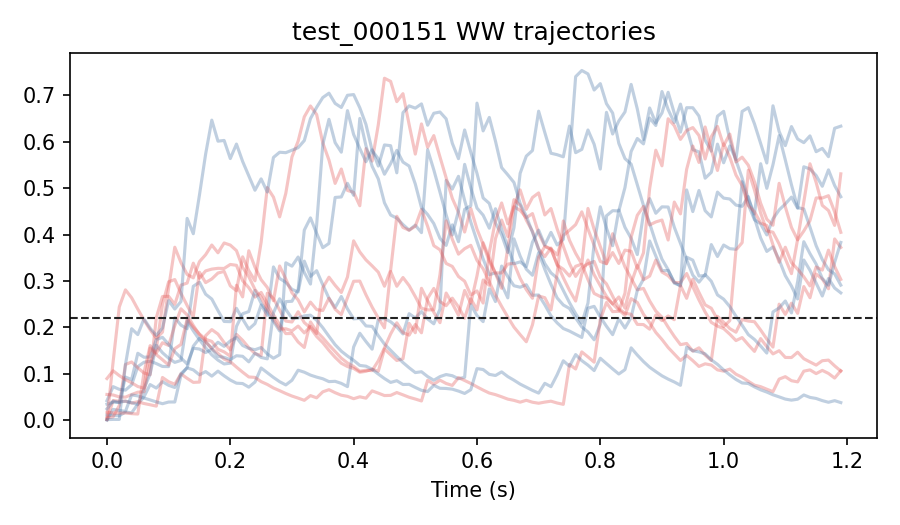

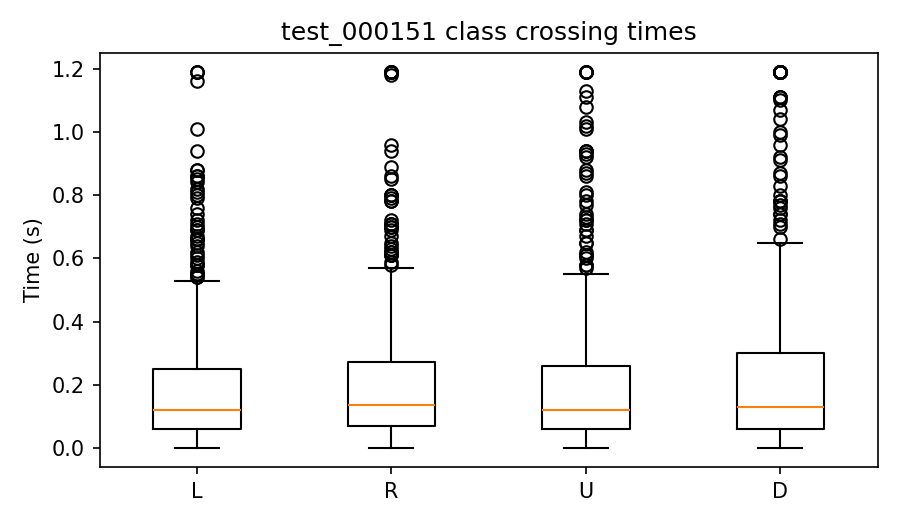

In [11]:
from IPython.display import Image, display as ipy_display
for i in range(min(3, len(selected))):
    for suffix in ["rt_hist", "rt_ecdf", "choice_counts", "evidence_samples", "dmc_modulated_evidence", "ww_trajectories", "crossing_times"]:
        path = FIG_DIR / f"trial_{i:03d}_{suffix}.png"
        if path.exists():
            ipy_display(Image(filename=str(path)))

# Section 12. Noise ablation

Four settings are compared:

1. Stage-1 evidence noise ON, WW internal noise ON
2. Stage-1 evidence noise ON, WW internal noise OFF
3. Stage-1 evidence noise OFF, WW internal noise ON
4. Stage-1 evidence noise OFF, WW internal noise OFF

Stage-1 noise OFF uses repeated `mu`; WW noise OFF sets internal noise to zero. DMC remains deterministic in all four settings.

,rt_std,error_probability,choice_consistency,q95_minus_q50
noise_condition,,,,
stage1_off_ww_off,1.665335e-16,0.500000,1.000000,0.000000
stage1_off_ww_on,7.985149e-02,0.730208,0.285937,0.164003
stage1_on_ww_off,2.507123e-03,0.500000,1.000000,0.003943
stage1_on_ww_on,8.226679e-02,0.726042,0.299479,0.164003


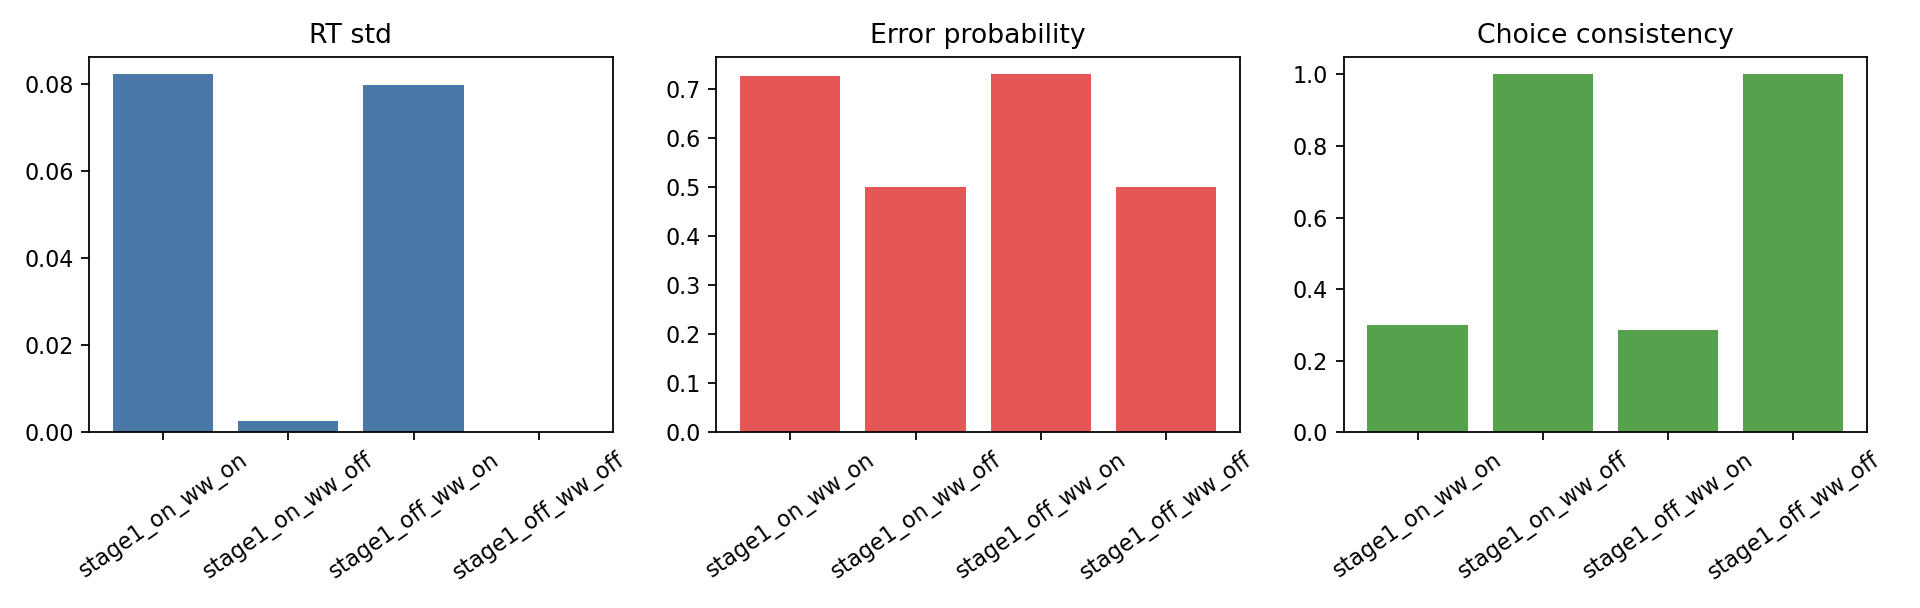

In [12]:
ablation = pd.read_csv(OUT_DIR / "noise_ablation_summary.csv")
display(ablation.groupby("noise_condition")[["rt_std", "error_probability", "choice_consistency", "q95_minus_q50"]].mean())
from IPython.display import Image, display as ipy_display
ipy_display(Image(filename=str(FIG_DIR / "noise_ablation_rt_variability.png")))

# Section 13. Condition-level vs single-trial comparison

Condition-level right tail may come from mixing many trials with different difficulty. Single-trial repeated right tail comes from stochastic dynamics inside the same fixed trial. These are different questions.

If single-trial distributions are narrow while condition-level distributions are broad, most variability is likely trial heterogeneity. If selected single-trial distributions are themselves broad or right-skewed, the model's internal stochastic dynamics can generate RT variability within one fixed trial.

In [13]:
comparison = dist_summary.merge(selected[["trial_id", "congruency", "human_rt", "human_correct", "reason_selected"]], on="trial_id")
display(comparison[["trial_id", "congruency", "human_rt", "mean_rt", "std_rt", "q95_minus_q50", "skewness", "choice_consistency", "reason_selected"]])

,trial_id,congruency,human_rt,mean_rt,std_rt,q95_minus_q50,skewness,choice_consistency,reason_selected
0,test_000030,congruent,0.690,0.425443,0.076141,0.162043,0.894478,0.336,congruent human-correct trial
1,test_000042,congruent,0.624,0.433033,0.075475,0.155769,0.615177,0.336,congruent human-error trial
2,test_000151,incongruent,0.571,0.426125,0.077232,0.156802,0.751746,0.282,incongruent human-correct trial
3,test_000498,incongruent,0.563,0.427839,0.085283,0.168122,1.198671,0.318,incongruent human-error trial
4,test_021835,incongruent,0.100,0.428093,0.077673,0.151685,0.723606,0.288,human fast RT trial
5,test_030475,congruent,1.190,0.425885,0.076820,0.162989,0.996177,0.280,human slow RT trial
6,test_009269,congruent,0.733,0.426876,0.078416,0.163927,0.807990,0.272,model likely fast-error trial
7,test_016903,congruent,0.657,0.432183,0.087042,0.183764,1.331086,0.270,model likely slow-correct trial
8,test_000187,congruent,0.530,0.429831,0.081563,0.164256,0.687860,0.302,additional target/flanker coverage
9,test_000337,incongruent,0.551,0.428339,0.076465,0.147286,0.606539,0.290,additional target/flanker coverage


# Section 14. Interpretation and take-home message

This notebook uses real human data plus current saved DMC + Var->WW artifacts for a diagnostic repeated-forward probe. It does not prove the final model is successful. It tests whether the current mechanism can generate single-trial stochastic RT variability after model parameters are fixed.

Use `overall_model_performance_summary.csv`, `single_trial_rt_distribution_summary.csv`, and `noise_ablation_summary.csv` as the compact tables for reporting. Use the figures folder for the slide-ready panels.

Important limitation: the current main pipeline does not save a formal repeated-forward export with trial-level `mu`, `sigma`, sampled evidence, DMC evidence, WW trajectories, and seeds. This notebook reconstructs a diagnostic probe from cached logits, saved WW/DMC parameters, and previous predictions.

Next steps: make the main pipeline export repeated-forward fields, consider temporally correlated evidence noise, and run Tubito-style counterfactual conflict injection to test how controlled conflict manipulation changes fast-error-like behavior.